In [3]:
%pip install openpyxl

Note: you may need to restart the kernel to use updated packages.


In [160]:
import urllib.request 
#웹에서 데이터를 다운로드하거나, HTTP 요청을 보내고 받을 때 사용하는 파이썬의 내장 모듈
#웹 페이지나 API로부터 데이터를 받아오기 위한 HTTP 요청 처리

import nltk
#nltk는 Natural Language Toolkit의 약자로, 자연어 처리를 위한 파이썬 라이브러리
#텍스트 데이터를 처리하고 분석하는 데 사용
#ex) 단어 토큰화, 불용어 제거, 형태소 분석 등에 사용

import pandas as pd
#pandas는 데이터 분석 및 조작을 위한 파이썬 라이브러리
#테이블 형식(엑셀, CSV 등)의 데이터를 다루고 처리하는 데 매우 유용

import glob
#파일 이름을 패턴 매칭으로 검색할 수 있는 모듈
#특정 경로에 있는 파일들을 와일드카드(*, ? 등)를 이용해 찾아 목록으로 반환하는 데 사용

import re
#정규 표현식(regular expressions)을 처리하는 모듈
#문자열 내에서 특정 패턴을 검색, 대체 또는 추출하는 데 사용

from functools import reduce
#reduce 함수는 리스트나 시퀀스를 누적하여 하나의 값으로 줄이는 함수
#여러 값을 하나의 값으로 결합해야 할 때 유용

from nltk.tokenize import word_tokenize
#word_tokenize는 NLTK의 텍스트 처리 함수로, 텍스트를 단어 단위로 분할
#문장을 단어 단위로 나누는 토큰화 작업을 위해 사용

from nltk.corpus import stopwords
#NLTK에서 제공하는 불용어 목록을 가져오는 모듈
#불용어는 텍스트 분석에서 자주 나타나지만 의미 없는 단어들(예: "the", "is", "in" 등)
#텍스트 데이터에서 자주 등장하지만 분석에 불필요한 단어들을 제거하기 위해 사용

from nltk.stem import WordNetLemmatizer
#WordNetLemmatizer는 단어의 원형을 추출하는 lemmatizer 객체를 제공
#단어의 어형을 원형으로 변환하여 분석을 쉽게 하려는 목적
#ex)"running"을 "run"으로 변환

from konlpy.tag import Okt
#Okt는 한국어 형태소 분석기, Konlpy는 한국어 자연어 처리를 위한 라이브러리
#한국어 텍스트 데이터를 처리하고 형태소 분석, 명사 추출, 품사 태깅 등을 수행하는 데 사용

from collections import Counter
#Counter는 collections 모듈의 클래스 중 하나로, 각 요소가 몇 번 등장했는지를 세어주는 도구
#리스트나 문자열에서 요소들의 빈도수를 계산하는 데 유용

import matplotlib as mpl
#matplotlib는 데이터 시각화를 위한 파이썬 라이브러리
#다양한 그래프와 차트를 생성하는 데 사용

import matplotlib.pyplot as plt
#matplotlib.pyplot은 그래프를 그리는 함수들을 제공하는 서브 모듈
#그래프, 차트, 플롯을 생성하여 데이터를 시각화하는 데 사용

from matplotlib import font_manager, rc
#font_manager와 rc는 matplotlib에서 폰트를 관리하고 설정하는 데 사용
#그래프의 폰트를 설정하여 한글이나 다른 언어를 올바르게 표시하거나, 특정 폰트를 지정하는 데 사용

from wordcloud import STOPWORDS, WordCloud
#WordCloud는 단어의 빈도를 시각적으로 표현하는 '워드클라우드'를 생성하는 도구
#STOPWORDS는 WordCloud에서 기본적으로 제외되는 불용어 목록
#텍스트 데이터의 빈도를 바탕으로 워드클라우드를 생성하여 시각화하는 데 사용

from PIL import Image
#PIL(Python Imaging Library)은 이미지 파일을 처리하는 라이브러리
#이미지 파일을 읽고, 처리하며, 변환하는 데 사용
import numpy as np

In [15]:
#아래는 한글을 사용할 때 깨지는 문제에 대한 해결
from matplotlib import font_manager, rc

font_name = font_manager.FontProperties(fname="/System/Library/Fonts/Supplemental/AppleGothic.ttf").get_name()
rc('font', family=font_name)
#윈도우
# font_name = font_manager.FontProperties(fname="c:/Windows/Fonts/malgun.ttf").get_name()
# rc('font', family=font_name)


#그래프의 축 등에서 음수를 표시할 때 minus sign이 깨지는 것 해결
mpl.rcParams['axes.unicode_minus'] = False

In [144]:
dfg = pd.read_excel('15_23세대별.xlsx', index_col = 0)
dfg

,2015,2016,2017,2018,2019,2020,2021,2022,2023
generation,,,,,,,,,
1g,3324418,3329335,3470070,3600264,3752000,3893435,4054467,4172590,4198385
2g,9328293,9361705,9320588,9288450,9209885,9201530,9049887,8918035,8857422
3g,1029196,998919,946500,893501,839928,759548,701095,662460,639542
4plus,11262,10678,9381,8012,6891,5384,4566,4183,3766
1p,5203440,5397615,5618677,5848594,6147516,6643354,7165788,7502350,7829035
ng,214421,269444,308659,340367,386968,423459,472660,513889,545008
total,19111030,19367696,19673875,19979188,20343188,20926710,21448463,21773507,22073158


In [146]:
dfh = pd.read_excel('15_23가구원수.xlsx', index_col = 0)
dfh

,2015,2016,2017,2018,2019,2020,2021,2022,2023
household_size,,,,,,,,,
1p,5203440.0,5397615.0,5618677.0,5848594.0,6147516.0,6643354.0,7165788.0,7502350.0,7829035.0
2p,4993818.0,5067166.0,5260332.0,5445691.0,5663330.0,5864525.0,6076549.0,6260692.0,6346314.0
3p,4100979.0,4151701.0,4178641.0,4203792.0,4217736.0,4200629.0,4169956.0,4184540.0,4194554.0
4p,3588931.0,3551410.0,3473897.0,3396320.0,3300114.0,3271315.0,3154286.0,3010697.0,2926453.0
5p,940413.0,924373.0,886479.0,849167.0,801048.0,761417.0,715982.0,664666.0,636293.0
6p,217474.0,211475.0,197517.0,182886.0,166866.0,147172.0,132665.0,120747.0,113086.0
7plus,65975.0,63956.0,58332.0,52738.0,46578.0,38298.0,33237.0,29815.0,27423.0
avg,2.5,2.5,2.5,2.4,2.4,2.3,2.3,2.2,2.2
total,19111030.0,19367696.0,19673875.0,19979188.0,20343188.0,20926710.0,21448463.0,21773507.0,22073158.0


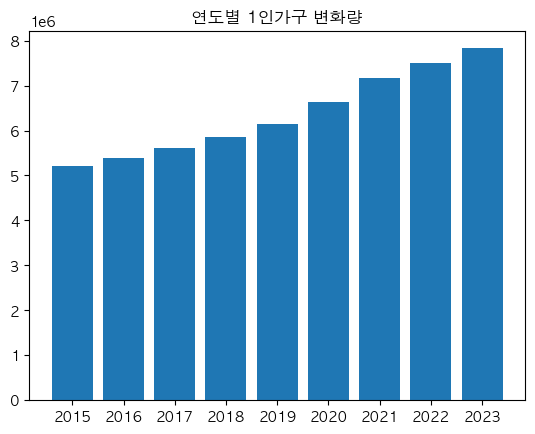

In [166]:
dfh = pd.read_excel('15_23가구원수.xlsx', index_col = 0)

x = np.arange(9)

plt.bar(x, dfh.loc['1p'])
plt.xticks(x, dfh.columns)

plt.title('연도별 1인가구 변화량')
plt.show()

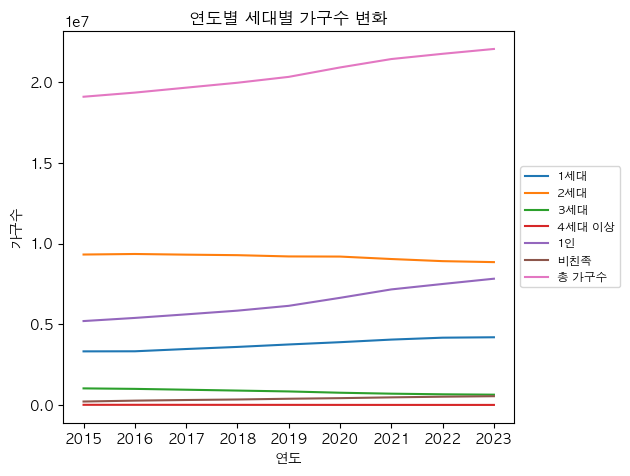

In [148]:
# 유효한 연도와 세대 라벨 설정
years = dfg.columns.tolist()  # 엑셀 파일의 열 이름(연도) 리스트 생성
labels = dfg.index.tolist()   # 엑셀 파일의 인덱스 이름(세대) 리스트 생성
labels_kr = ['1세대', '2세대', '3세대', '4세대 이상', '1인', '비친족', '총 가구수']  # 한글 라벨 리스트

# 각 세대별 그래프 그리기
for label, label_kr in zip(labels, labels_kr):
    plt.plot(years, dfg.loc[label, years], label=label_kr)

# 그래프 레이블 설정
plt.xlabel('연도')
plt.ylabel('가구수')

# 범례 위치 및 크기 조정
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='small')

# 그래프 출력
plt.tight_layout()  # 그래프 요소가 잘리지 않도록 레이아웃 조정
plt.title('연도별 세대별 가구수 변화')
plt.show()

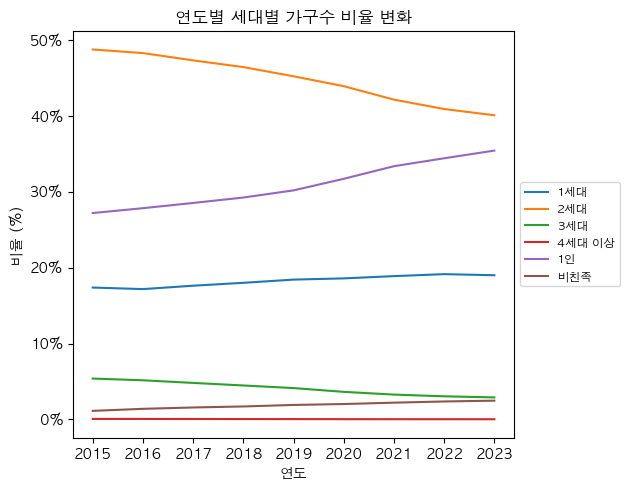

In [154]:
import matplotlib.ticker as ticker
# 유효한 연도와 세대 라벨 설정
years = dfg.columns.tolist()  # 엑셀 파일의 열 이름(연도) 리스트 생성
labels = dfg.index.tolist()   # 엑셀 파일의 인덱스 이름(세대) 리스트 생성
labels_kr = ['1세대', '2세대', '3세대', '4세대 이상', '1인', '비친족', '총 가구수']  # 한글 라벨 리스트

# '총 가구수' 제외하고 나머지 세대만 선택
labels_no_total = labels[:-1]  # 마지막 항목이 '총 가구수'이므로 제외
labels_kr_no_total = labels_kr[:-1]

# 각 세대별 비율 계산: dfg / '총 가구수'
dfg_percent = dfg.div(dfg.loc['total'], axis=1) * 100

# 각 세대별 그래프 그리기 (총 가구수를 제외한 세대만)
for label, label_kr in zip(labels_no_total, labels_kr_no_total):
    plt.plot(years, dfg_percent.loc[label, years], label=label_kr)

# 그래프 레이블 설정
plt.xlabel('연도')
plt.ylabel('비율 (%)')

# y축을 % 단위로 표시
plt.gca().get_yaxis().set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

# 범례 위치 및 크기 조정
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='small')

# 그래프 출력
plt.tight_layout()  # 그래프 요소가 잘리지 않도록 레이아웃 조정
plt.title('연도별 세대별 가구수 비율 변화')
plt.show()